# Python interfaces to EPA's Air Quality System (AQS)

## The EPA AQS

The EPA regulatory database is the Air Quality System (AQS). This database contains ambient air data from thousands of monitors. Many groups contribute to this database including the US EPA, state, local, and tribal air pollution control agencies. In addition to air quality, the AQS contains meteorological data, and metadata about the location of the monitoring site including the address, latitude/longitude, local site name, operator, where the ambient data are collected as well as information about the types of monitors used to collect the ambient measurements.

Information related to quality assurance (QA) and quality control (QC) are also contained in the AQS. Because the quality assurance process takes time, the AQS data are not real-time. While agencies generally have 3 months to collect, analyze, compute, and quality assure the values before loading the data into AQS, it can take up to 6 months for data to reach AQS. This QA and QC is essential, because the AQS serves as the basis of regulatory actions.

This script provides examples which use the EPA's *pyaqsapi* package: A python module for accessing the EPA's Air Quality System (AQS) data using the EPA AQS Application Programming Interface (API), the tools and protocols used to interact with the AQS system. See the URL below for more details about the EPA API. 

https://aqs.epa.gov/aqsweb/documents/data_api.html


This notebook begins by downloading pyaqsapi from GitHub, and installing it on your system. After installation, it helps you register your email address with the EPA to obtain a key to use the AQS API. Once you are registered, this script explores a few features of pyaqsapi. Documentation for pyaqsapi can be found at https://usepa.github.io/pyaqsapi/. 


explain aqs, airdata and airnow


## Import standard Python libraries

In [1]:
import numpy as np            # Numerical Python: scientific 
import pandas as pd           # Tabular data and time series package
import matplotlib as plt      # Data visualization libraries
import datetime as dt         # Manipulate basic dates and times 

### PYAQSAPI Installation

If pyaqsapi is not installed on your system, open a terminal and run the line below to install pyaqsapi. If you have the PowerShell extension installed, you can run it in the box below.

`pip install git+https://github.com/USEPA/pyaqsapi`

Load the pyaqsapi library and check the version number

In [3]:
import pyaqsapi as aqs                        # Any text after a pound sign is regarded as a comment
from importlib.metadata import version
version('pyaqsapi')

'1.0b0'

### Registration

You need to supply a registered email address and your key when you make calls to the EPA's AQS API. To register, you can modifying the URL below (the 'signup' endpoint) by replacing <i>myemail@example.com</i> with your email address and then pasting it in the address bar of your web browser.

 https://aqs.epa.gov/data/api/signup?email=myemail@example.com 


If you have done this successfully, a key will be mailed to the address you supplied. You can also sign from within this notebook using pyaqsapi's aqs_sign_up() function.  To do so, uncomment the code below be deleting the first #, then modify the command to include your email address. After you run the command you will be emailed a key. 

In [ ]:

aqs.aqs_sign_up("youremail@neiu.edu")    # Uncomment this line and run it to sign up for the data mart.

If you have run the command above, check your email for a key. You will need this below. 

Entering your email and key gets tiresome and repetitive after a while. Pyaqsapi.aqs_credentials() sets your credentials so that you only need to call it once every time the pyaqsapi library is reloaded. Below we create variables for your username (email) and key. Edit the command by replacing the email address the email address you used when you registered for the AQS API, and replacing 'yourkey' with the key that was emailed to you when you signed up

In [5]:
#datamart_user = "your_username@neiu.edu"
#datamart_key = "the_key_you_received_by_email"
datamart_user = "g-anderson@neiu.edu"
datamart_key = "goldbird83"

In [6]:
aqs.aqs_credentials(username = datamart_user,key=datamart_key)    # set your credentials

## AQS API Services

The EPA AQS API provides several services. These services are described at

https://aqs.epa.gov/aqsweb/documents/data_api.html#services

The location where the API sends a request is known as the endpoint, a URL containing the server address and service requested. The 'sign up' URL above is one example of an endpoint in the API. While you can access the AQS Data Mart by typing URLs which are directed at an "endpoint" directly into the address bar of your browser, that process is cumbersome. The pyaqsapi package allows you to make these calls from within a jupyter notebook using pyaqsapi functions. 

These endpoints allow you to access and import data directly into a notebook, and explore what information is available. A list of pyaqsapi functions can be found at: 

https://usepa.github.io/pyaqsapi/genindex.html

Pyaqsapi is a port of R package RAQSAPI to the python 3 programming environment. They are intended to have the same functionality so some of the documentation for RAQSAPI will be useful to pyaqsapi users. See for example:

https://cloud.r-project.org/web/packages/RAQSAPI/RAQSAPI.pdf
https://cran.r-project.org/web/packages/RAQSAPI/vignettes/RAQSAPIvignette.html

When accessing information from the AQS API you will need to specify the time, location, and what kind of data you wish to access

### Parameter Classes

Parameter classes are groupings of parameters, for example criteria pollutants or meteorological parameters. Run function below to see a list of classes, ...
The command below should display the classes in the Python box.  For most applications, the most useful classes on that list are:

- **CRITERIA:**  for criteria pollutants
- **MET:** for meteorological (weather) parameters
- **HAPS:** Hazardous Air pollutants
- **CORE_HAPS:** Urban Air Toxic pollutants

In [7]:
aqs.aqs_classes()    # List the AQS classes

,code,value_represented
0,AIRNOW MAPS,The parameters represented on AirNow maps (881...
1,ALL,Select all Parameters Available
2,AQI POLLUTANTS,Pollutants that have an AQI Defined
3,CORE_HAPS,Urban Air Toxic Pollutants
4,CRITERIA,Criteria Pollutants
5,CSN DART,List of CSN speciation parameters to populate ...
6,FORECAST,Parameters routinely extracted by AirNow (STI)
7,HAPS,Hazardous Air Pollutants
8,IMPROVE CARBON,IMPROVE Carbon Parameters
9,IMPROVE_SPECIATION,PM2.5 Speciated Parameters Measured at IMPROVE...


The aqs_parameters_by_class() function can be used to return numerical codes for CRITERIA pollutants. 
This information can also be found at https://www.epa.gov/aqs/aqs-code-list

In [3]:
aqs.aqs_parameters_by_class('CRITERIA')

Please use the aqs_credentials  function to enter your credentials before using this function


""


We can use the numerical codes listed by the commend above directly, but if we define names to store these values, our code below will be easier read.This way you don't have to remember 44201 is ozone!

In [38]:
CRITERIA_O3    = "44201"   # Ozone (O3) 
CRITERIA_NO2   = "42602"   # Nitrogen dioxide (NO2)
CRITERIA_CO    = "42101"   # Carbon monoxide (CO)
CRITERIA_PM25  = "88101"   # PM 2.5
CRITERIA_PM10  = "88102"   # PM 10
CRITERIA_SO2   = "42401"   # Sulfur dioxide

The command below lists the meteorological (MET) parameters. We don't need to execute this command to run the code in this script, but the list shows us the values of the MET parameters used below.

In [4]:
aqs.aqs_parameters_by_class("MET")

Please use the aqs_credentials  function to enter your credentials before using this function


""


The parameters in the MET class that we may want to use include:

In [49]:
MET_RAD = "63301"      # Solar radiation
MET_UV = "63302"       # Ultraviolet Radiation UV
MET_MX = "61301"       # Mixing Height
MET_TEMP = "62101"     # Outdoor temperature

MET_WIND_Sp = "61101"      # Wind Speed -scalar
MET_WIND_DIR = "61102"     # Wind Direction -scalar
MET_WIND_DIR_RES = "61104" # Wind Direction -Resultant
MET_WIND_GUST ="61105"     # Peak Wind Gust

The command below lists the Hazardous Air Pollutants (HAPS) parameters. 

In [25]:
HAPS_parameters = aqs.aqs_parameters_by_class('HAPS')
CORE_HAPS_parameters = aqs.aqs_parameters_by_class('CORE_HAPS')

from IPython.display import display, HTML

pd.set_option("display.max_rows", None)
display(HTML("<div style='height: 150px'>" + HAPS_parameters.style.to_html() + "</div>"))
display(HTML("<div style='height: 150px'>" + CORE_HAPS_parameters.style.to_html() + "</div>"))

HAPS_CH2O = "43502" # formaldehyde
HNO3 = "42305" # Nitric Acid AQS Parameter Code


,code,value_represented
0,11103,Benzene soluble organics (TSP)
1,11300,Radionucleides
2,11343,Antimony - 121 (TSP)
3,11344,Arsenic - 75 (TSP)
4,11345,Chromium - 50 (TSP)
5,11346,Chromium - 52 (TSP)
6,11347,Chromium - 53 (TSP)
7,11348,Cobalt - 59 (TSP)
8,11351,Lead - 208 (TSP)
9,11352,Manganese - 55 (TSP)


,code,value_represented
0,12103,Arsenic (TSP) STP
1,12105,Beryllium (TSP) STP
2,12110,Cadmium (TSP) STP
3,12112,Chromium (TSP) STP
4,12115,Chromium VI (TSP) STP
5,12128,Lead (TSP) STP
6,12132,Manganese (TSP) STP
7,12136,Nickel (TSP) STP
8,14115,Chromium VI (TSP) LC
9,43218,"1,3-Butadiene"


Volatile Organic Compounds

In [26]:
VOC_parameters = aqs.aqs_parameters_by_class('VOC')
display(HTML("<div style='height: 100px'>" + VOC_parameters.style.to_html() + "</div>"))

,code,value_represented
0,42153,Carbon disulfide
1,43000,Sum of PAMS target compounds
2,43102,Total NMOC (non-methane organic compound)
3,43202,Ethane
4,43203,Ethylene
5,43204,Propane
6,43205,Propylene
7,43206,Acetylene
8,43207,Freon 113
9,43208,Freon 114


### Location


The ArcGIS Application for EPA Air Quality Monitors  (https://www.ndbc.noaa.gov/) linked in the image below, is a convenient way to identify stations and measurements. 

[![ArcGIS Screenshot](images/arcgis_screenshot.png)](https://epa.maps.arcgis.com/apps/webappviewer/index.html?id=5f239fd3e72f424f98ef3d5def547eb5)

#### Finding monitors with function calls

Monitors can be found and accessed by State-Count-Site, a bounding box of latitude and longtitude, or 
by CBSA. 

The US Office of Management and Budget created core-based statistical areas (CBSAS). EPA's AQS can be queried by CBSAS. Get codes for Core Base Statistical Areas (CBSAS):

In [64]:
cbas_list = aqs.aqs_cbsas()
display(HTML("<div style='height: 100px'>" + cbas_list.style.to_html() + "</div>"))

,code,value_represented
0,10020,"Abbeville, LA"
1,10100,"Aberdeen, SD"
2,10140,"Aberdeen, WA"
3,10180,"Abilene, TX"
4,10220,"Ada, OK"
5,10260,"Adjuntas, PR"
6,10300,"Adrian, MI"
7,10380,"Aguadilla-Isabela, PR"
8,10420,"Akron, OH"
9,10460,"Alamogordo, NM"


Create names for local CBSAS codes:

In [8]:
Chicagoland = "16980"   # Chicago-Naperville-Elgin, IL-IN-WI
Milwaukeeland = "33340" # Milwaukee-Waukesha-West Allis, WI
Sheboyganland = "43100" # Sheboygan Metro
MichiganCityland = "33140"  # Michigan CityLa Porte, IN Metro

<h4>FIPS Codes</h4>

The command below produces a list the Federal Information Processing Standards (FIPS) state numbers that are needed in some function calls. These numbers are also available online at many locations, see for example:

https://en.wikipedia.org/wiki/Federal_Information_Processing_Standard_state_code

In [28]:
state_fips = aqs.aqs_states()
state_fips
display(HTML("<div style='height: 100px'>" + state_fips.style.to_html() + "</div>"))

,code,value_represented
0,01,Alabama
1,02,Alaska
2,04,Arizona
3,05,Arkansas
4,06,California
5,08,Colorado
6,09,Connecticut
7,10,Delaware
8,11,District Of Columbia
9,12,Florida


Create FIPS code variable names for local state FIPS numbers. EPA Region V contains these states.

In [29]:
IL_FIPS = "17"      # Illinois FIPS code
IN_FIPS = "18"      # Indiana FIPS code
WI_FIPS = "55"      # Wisconsin FIPS code
MI_FIPS = "26"      # Michigan FIPS code
MN_FIPS = "27"      # Minnesota FIPS code
OH_FIPS = "39"      # Ohio FIPS code

Counties also have numeric codes. Use the functions below to get county code numbers for states with a border in Lake Michigan:

In [ ]:
aqs.aqs_counties_by_state(IL_FIPS)    # County codes in Illinois
aqs.aqs_counties_by_state(IN_FIPS)    # County codes in Indiana
aqs.aqs_counties_by_state(WI_FIPS)    # County codes in Wisconsin
aqs.aqs_counties_by_state(MI_FIPS)    # County codes in Michigan

Create descriptive names for selected county codes:

Indiana Lakefront counties W to E

In [31]:
IN_Lake_Co = "089"
IN_Porter_Co = "127"
IN_LaPorte_Co = "091"

Lakefront IL Counties N to S

In [32]:
IL_Lake_Co = "097"
IL_Cook_Co = "031"

Lakefront WI Counties S to N

In [33]:
WI_Kenosha_Co = "059"  
WI_Racine_Co = "101"
WI_Milwaukee_Co = "079"
WI_Ozaukee_Co = "089"
WI_Sheboygan_Co = "117"
WI_Manitowoc_Co = "071"
WI_Kewaunee_Co = "061"
WI_Door_Co = "029"

MI Lakefront counties N to S

In [34]:
MI_Oceana_Co = "26127"
MI_Muskegon_Co = "6121"
MI_Ottawa_Co = "26139"
MI_Van_Buren_Co = "26159"
MI_Allegan_Co = "26005"
MI_Berrien_Co = "26021"

Use the AQS to find Station IDs in each county

In [14]:
aqs.aqs_sites_by_county(stateFIPS=IN_FIPS,countycode=IN_Porter_Co)
aqs.aqs_sites_by_county(stateFIPS=IN_FIPS,countycode=IN_Lake_Co)
aqs.aqs_sites_by_county(stateFIPS=IL_FIPS,countycode=IL_Cook_Co)
aqs.aqs_sites_by_county(stateFIPS=IL_FIPS,countycode=IL_Lake_Co)
aqs.aqs_sites_by_county(stateFIPS=WI_FIPS,countycode=WI_Kenosha_Co)
aqs.aqs_sites_by_county(stateFIPS=WI_FIPS,countycode=WI_Racine_Co)
aqs.aqs_sites_by_county(stateFIPS=WI_FIPS,countycode=WI_Milwaukee_Co)
aqs.aqs_sites_by_county(stateFIPS=WI_FIPS,countycode=WI_Ozaukee_Co)

,code,value_represented
0,0001,None
1,0002,None
2,0004,None
3,0005,None
4,0006,None
5,0007,None
6,0008,GRAFTON
7,0009,HARRINGTON BEACH PARK
8,0899,None
9,0999,None


Create names to store selected station IDs from the lists above

In [36]:

Muskegon_MI = "0039" # 26-121-0039
Holland_MI  = "0003" # 26-005-0003
Coloma_MI   = "0014"  # 26-021-0014  (Benton Harbor)

Michigan_City_IN = "0005" # Laporte, IN
Ogden_IN = "0024"         # Porter, IN
Gary_IN = "0022"          # Lake, IN
Hammond_IN = "2008"       # Lake, IN

South_Water_IL = "0032"  # Cook, IL
Com_Ed_Maint_IL = "0076" # NO2 station near South Water
Northbrook_WP = "4201"
Evanston_WP = "7002"      # Evanston Water Plant
Camp_Logan = "1007"

Chiwaukee_Prairie = "0019"  # 55-059-0019
Kenosha_WI ="0025"          # 55-059-0025 Kenosha Water Tower
Racine_WI = "0020"          # 55-101-0020 Racine Co

Waukesha_WI ="0027"         # 55-133-0027 Cleveland Ave
Milwaukee_WI = "0026"       # Milwaukee North
Milwaukee_South = "0056"    # 55-079-0010 Milwaukee Co

Bayside_WI ="0085"          # 55-079-0085
Harrington_Beach ="0009"    # Ozaukee ="089"
Sheboygan_WI="0006"         #
Manitowoc_WI = "0007"       #

Kewaunee_WI = "0002"
Newport_Park_WI = "0004"

<h3>Services</h3>

Complete function calls are of the form aqs.submodule.function(), where the seven submodules are: 
<ul>
<li>bysite <li>bycounty <li>bystate <li>bycbsa <li>bybox <li>byma <li> bypqao
</ul>

The submodule functions include services like: sampledata(), dailysummary(), quarterlysummar(), annualsummary(), and monitors().  sampledata() is the most fine grained data reported to EPA. Each of these functions has required arguments like the time interval, location, and parameter so be used.  Several examples are listed below.


What ozone monitors were at the Evanston Water Plant in 2020?

In [40]:
aqs.bysite.monitors(parameter=CRITERIA_O3,  
                     bdate=dt.datetime(2020,1,1),
                     edate=dt.datetime(2020,12,31),
                     stateFIPS=IL_FIPS,
                     countycode=IL_Cook_Co,
                     sitenum=Evanston_WP)

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,031,7002,44201,1,Ozone,1977-08-01,None,None,None,...,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None


The function above is using an endpoint like the URL below if you replace the email address and key with your credentials.

https://aqs.epa.gov/data/api/monitors/bySite?email=test@aqs.api&key=test&param=44201&bdate=20200101&edate=20201231&state=17&county=031&site=7002



Uncomment the code block below to create a data frame of Cook County Ozone monitors

In [ ]:
#Cook_IL_monitors = aqs.aqs_sites_by_county(stateFIPS=IL_FIPS,countycode=IL_Cook_Co)
#Cook_IL_monitors

PM2.5 Monitors in Cook county in 2020

In [60]:
Cook_IL_pm25_monitors = aqs.bycounty.monitors(stateFIPS=IL_FIPS,
                                            countycode=IL_Cook_Co,
                                            bdate=dt.datetime(2020,1,1),
                                            edate=dt.datetime(2020,12,31),
                                            parameter=CRITERIA_PM25)

display(HTML("<div style='height: 150px'>" + Cook_IL_pm25_monitors.style.to_html() + "</div>"))

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,measurement_scale,measurement_scale_def,monitoring_objective,last_method_code,last_method_description,last_method_begin_date,naaqs_primary_monitor,qa_primary_monitor,monitor_type,networks,monitoring_agency_code,monitoring_agency,si_id,latitude,longitude,datum,lat_lon_accuracy,elevation,probe_height,pl_probe_location,local_site_name,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,031,0001,88101,1,PM2.5 - Local Conditions,2013-04-01,None,None,AREA,NEIGHBORHOOD,500 M TO 4KM,POPULATION EXPOSURE,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,2019-06-20,Y,None,SLAMS,None,0513,Illinois Environmental Protection Agency,3652,41.670992,-87.732457,WGS84,5.000000,188.000000,8.000000,TOP OF BUILDING,VILLAGE GARAGE,4500 W. 123RD ST.,Illinois,Cook,Alsip,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
1,17,031,1016,88101,9,PM2.5 - Local Conditions,2013-04-01,2023-12-31,PM25 Annual 2012 (2013-04-01 - 2023-12-31); PM25 Annual 2006 (2013-04-01 - 2023-12-31),AREA,MIDDLE SCALE,100 M TO 500 M,POPULATION EXPOSURE; SOURCE ORIENTED,143,R & P Model 2000 PM-2.5 Air Sampler w/VSCC - Gravimetric,2017-01-01,None,None,None,None,0513,Illinois Environmental Protection Agency,3734,41.801180,-87.832349,WGS84,10.000000,186.000000,6.000000,TOP OF BUILDING,VILLAGE HALL,50TH ST. AND GLENCOE,Illinois,Cook,McCook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
2,17,031,0022,88101,1,PM2.5 - Local Conditions,1999-01-01,None,None,POINT,NEIGHBORHOOD,500 M TO 4KM,POPULATION EXPOSURE; SOURCE ORIENTED,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,2021-11-09,Y,Y,SLAMS,None,0513,Illinois Environmental Protection Agency,3673,41.687165,-87.539315,WGS84,5.000000,178.000000,9.000000,TOP OF BUILDING,WASHINGTON HS,3535 E. 114TH ST.,Illinois,Cook,Chicago,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
3,17,031,3301,88101,9,PM2.5 - Local Conditions,2013-01-01,None,None,AREA,NEIGHBORHOOD,500 M TO 4KM,POPULATION EXPOSURE,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,2019-12-23,None,None,SLAMS,None,0513,Illinois Environmental Protection Agency,3771,41.782766,-87.805377,WGS84,20.000000,190.000000,6.000000,TOP OF BUILDING,GRAVES ES,60TH ST. & 74TH AVE.,Illinois,Cook,Summit,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
4,17,031,4201,88101,3,PM2.5 - Local Conditions,2016-12-01,None,None,AREA,URBAN SCALE,4 KM TO 50 KM,POPULATION EXPOSURE,638,Teledyne T640X at 16.67 LPM w/Network Data Alignment enabled - Broadband spectroscopy,2023-11-01,Y,Y,SLAMS,NCORE,0513,Illinois Environmental Protection Agency,3783,42.139996,-87.799227,WGS84,10.000000,198.000000,8.000000,TOP OF BUILDING,NORTHBROOK WATER PLANT,750 DUNDEE ROAD,Illinois,Cook,Northbrook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
5,17,031,0119,88101,3,PM2.5 - Local Conditions,2019-03-01,None,None,MOBILE,MICROSCALE,0 M TO 100 M,HIGHEST CONCENTRATION; SOURCE ORIENTED,636,Teledyne T640 at 5.0 LPM w/Network Data Alignment enabled - Broadband spectroscopy,2023-11-01,Y,None,SLAMS,NEAR ROAD,0513,Illinois Environmental Protection Agency,104496,41.578620,-87.557406,NAD83,1.000000,1.000000,nan,TOP OF BUILDING,Kingery Near Road #1,KINGERY EXPRESSWAY & TORRENCE AVENUE,Illinois,Cook,Lansing,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
6,17,031,0076,88101,1,PM2.5 - Local Conditions,2000-01-01,None,None,AREA,NEIGHBORHOOD,500 M TO 4KM,POPULATION EXPOSURE,545,Met One E-SEQ-FRM PM2.5 with VSCC - Gravimetric,2021-06-01,Y,None,SLAMS,None,0513,Illinois Environmental Protection Agency,3721,41.751400,-87.713488,WGS84,5.000000,186.000000,5.000000,TOP OF BUILDING,COM ED MAINTENANCE BLDG,7801 LAWNDALE,Illinois,Cook,Chicago,

Create a list of UV Monitors in IL

In [50]:
il_uv_monitors = aqs.bystate.monitors(parameter=MET_UV,
                              bdate=dt.datetime(2020,1,1),
                              edate=dt.datetime(2020,12,31),           
                              stateFIPS=IL_FIPS) 
display(il_uv_monitors)

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,031,4201,63302,1,Ultraviolet radiation,2012-01-01,None,None,AREA,...,750 DUNDEE ROAD,Illinois,Cook,Northbrook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None


In 2020 the MET_UV sites in Illinois included: 4201 - the Northbrook Water Plant

In [ ]:
il_uv_monitors.loc[:'site_number'].drop_duplicates() # List unique site numbers

You can modify the command above to verify the following:
MET_UV sites in Illinois 2020: 4201 - the Northbrook Water Plant
MET_RAD sites in Illinois 2020: 4201, 9001, 1001

In [51]:
il_rad_monitors =aqs.bystate.monitors(parameter=MET_RAD,
                            bdate=dt.datetime(2020,1,1),
                            edate=dt.datetime(2020,12,31),           
                            stateFIPS=IL_FIPS)  
display(il_rad_monitors)

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,019,1001,63301,1,Solar radiation,2011-01-01,None,None,None,...,TWP RD 500 E.,Illinois,Champaign,Bondville,16580,"Champaign-Urbana, IL",None,None,None,None
1,17,031,4201,63301,1,Solar radiation,1997-05-15,None,None,AREA,...,750 DUNDEE ROAD,Illinois,Cook,Northbrook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
2,17,133,9001,63301,1,Solar radiation,2016-04-01,None,None,None,...,"Off Ivy Road, Fults, IL, 62244",Illinois,Monroe,Not in a City,41180,"St. Louis, MO-IL",476,"St. Louis-St. Charles-Farmington, MO-IL",None,None


Radiation measurements (MET_RAD sites) in Illinois 2020: 4201, 9001, 1001

In [ ]:
il_rad_monitors.loc[:'site_number'].drop_duplicates()  # List unique site numbers

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,019,1001,63301,1,Solar radiation,2011-01-01,None,None,None,...,TWP RD 500 E.,Illinois,Champaign,Bondville,16580,"Champaign-Urbana, IL",None,None,None,None
1,17,031,4201,63301,1,Solar radiation,1997-05-15,None,None,AREA,...,750 DUNDEE ROAD,Illinois,Cook,Northbrook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
2,17,133,9001,63301,1,Solar radiation,2016-04-01,None,None,None,...,"Off Ivy Road, Fults, IL, 62244",Illinois,Monroe,Not in a City,41180,"St. Louis, MO-IL",476,"St. Louis-St. Charles-Farmington, MO-IL",None,None


Finding monitors by CBSA (Chicagoland has Sites 0022 and 4201)

In [30]:
chicagoland_uv_monitors =aqs.bycbsa.monitors(parameter=MET_UV,
                             bdate=dt.datetime(2020,1,1),
                             edate=dt.datetime(2020,12,31),
                             cbsa_code = Chicagoland)  

display(chicagoland_uv_monitors)

,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,...,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,031,4201,63302,1,Ultraviolet radiation,2012-01-01,None,None,AREA,...,750 DUNDEE ROAD,Illinois,Cook,Northbrook,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
1,18,089,0022,63302,1,Ultraviolet radiation,2000-01-01,None,None,POINT,...,"201 MISSISSIPPI ST., IITRI BUNKER",Indiana,Lake,Gary,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None


The Bounding Box below roughly encloses Lake Michigan and the surrounding shoreline. This command below looks for monitors inside that box. 


In [63]:
box_o3_monitors = aqs.bybox.monitors(parameter=CRITERIA_O3,
                            bdate=dt.datetime(2020,1,1),
                            edate=dt.datetime(2020,12,31),
                            minlat="41",
                            maxlat="46.5",
                            minlon="-89",
                            maxlon="-85")

display(HTML("<div style='height: 150px'>" + box_o3_monitors.style.to_html() + "</div>"))


,state_code,county_code,site_number,parameter_code,poc,parameter_name,open_date,close_date,concurred_exclusions,dominant_source,measurement_scale,measurement_scale_def,monitoring_objective,last_method_code,last_method_description,last_method_begin_date,naaqs_primary_monitor,qa_primary_monitor,monitor_type,networks,monitoring_agency_code,monitoring_agency,si_id,latitude,longitude,datum,lat_lon_accuracy,elevation,probe_height,pl_probe_location,local_site_name,address,state_name,county_name,city_name,cbsa_code,cbsa_name,csa_code,csa_name,tribal_code,tribe_name
0,17,043,6001,44201,1,Ozone,1984-01-01,None,None,AREA,URBAN SCALE,4 KM TO 50 KM,POPULATION EXPOSURE,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,2013-07-02,Y,None,SLAMS,None,0513,Illinois Environmental Protection Agency,3818,41.813049,-88.072827,WGS84,10.000000,206.000000,14.000000,None,MORTON ARBORETUM,RT. 53,Illinois,DuPage,Lisle,16980,"Chicago-Naperville-Elgin, IL-IN-WI",176,"Chicago-Naperville, IL-IN-WI",None,None
1,26,105,0007,44201,1,Ozone,1998-04-01,None,None,None,REGIONAL SCALE,50 TO HUNDREDS KM,MAX OZONE CONCENTRATION,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,2006-04-01,Y,None,SLAMS,None,0685,"Michigan Dept Of Environment, Great Lakes, and Energy-Air Quality Division",7596,43.953334,-86.294415,WGS84,15.180000,0.000000,nan,None,SCOTTVILLE - LOCATED 550 FT NORTH OF US10,525 W US10 (SCOTTVILLE),Michigan,Mason,Scottville,31220,"Ludington, MI",None,None,None,None
2,55,029,0004,44201,1,Ozone,1989-04-15,None,None,AREA,NEIGHBORHOOD,500 M TO 4KM,REGIONAL TRANSPORT,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,1996-04-15,Y,None,SLAMS,None,1175,"Wisconsin Dept Of Natural Resources, Air Monitoring Section",17092,45.238400,-86.994000,NAD83,2.000000,195.000000,12.000000,TOWER,NEWPORT PARK,475 Newport Park Rd,Wisconsin,Door,Not in a City,None,None,None,None,None,None
3,55,061,0002,44201,1,Ozone,1994-04-06,None,None,AREA,NEIGHBORHOOD,500 M TO 4KM,MAX OZONE CONCENTRATION; REGIONAL TRANSPORT,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,1996-04-15,Y,None,SLAMS,None,1175,"Wisconsin Dept Of Natural Resources, Air Monitoring Section",17223,44.443120,-87.505250,WGS84,2.000000,207.000000,6.000000,TOP OF BUILDING,KEWAUNEE,1630 Milwaukee St,Wisconsin,Kewaunee,Kewaunee,24580,"Green Bay, WI",267,"Green Bay-Shawano, WI",None,None
4,55,079,0026,44201,1,Ozone,1999-06-01,2021-04-09,None,AREA,NEIGHBORHOOD,500 M TO 4KM,POPULATION EXPOSURE,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,2000-06-02,Y,None,SLAMS,UNOFFICIAL PAMS,1175,"Wisconsin Dept Of Natural Resources, Air Monitoring Section",17318,43.060975,-87.913504,WGS84,5.000000,208.000000,6.000000,TOP OF BUILDING,MILWAUKEE - SER DNR HDQRS,2300 N M. L. KING JR DR,Wisconsin,Milwaukee,Milwaukee,33340,"Milwaukee-Waukesha-West Allis, WI",376,"Milwaukee-Racine-Waukesha, WI",None,None
5,18,141,0015,44201,1,Ozone,2006-06-01,None,None,MOBILE,NEIGHBORHOOD,500 M TO 4KM,HIGHEST CONCENTRATION; POPULATION EXPOSURE,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,2021-05-17,Y,None,SLAMS,None,0520,Indiana Depart Of Environ Management/Office Of Air Quality,93402,41.696660,-86.214722,NAD83,5.000000,181.000000,4.200000,TOP OF BUILDING,South Bend-Shields Dr.,2335 SHIELDS DR/ SOUTH BEND CAAP 2,Indiana,St. Joseph,South Bend,43780,"South Bend-Mishawaka, IN-MI",515,"South Bend-Elkhart-Mishawaka, IN-MI",None,None
6,18,141,0016,44201,1,Ozone,2012-04-01,None,None,None,URBAN SCALE,4 KM TO 50 KM,HIGHEST CONCENTRATION; POPULATION EXPOSURE,047,INSTRUMENTAL - ULTRA VIOLET,2012-04-01,Y,None,SLAMS,None,0520,Indiana Depart Of Environ Management/Office Of Air Quality,96806,41.754722,-86.110000,NAD83,10.000000,215.800000,13.100000,TOP OF BUILDING,Granger-Beckley St.,"Granger- Beckley St. 12441 Beckley. St., Granger",Indiana,St. Joseph,Granger,43780,"South Bend-Mishawaka, IN-MI",515,"South Bend-Elkhart-Mishawaka, IN-MI",None,None
7,55,087,0009,44201,1,Ozone,1995-04-15,None,None,AREA,URBAN SCALE,4 KM TO 50 KM,MAX OZONE CONCENTRATION,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,1996-05-17,Y,None,SLAMS,

Get data by bounding box. Note, sampledata() returns is the finest grained data available from the EPA AQS.

In [54]:

uv_data =aqs.bybox.sampledata(parameter=MET_UV,
                            bdate=dt.datetime(2020,5,1),
                            edate=dt.datetime(2020,5,31),
                            minlat="41",
                            maxlat="46.5",
                            minlon="-89",
                            maxlon="-85")

In [ ]:
display(uv_data)

Summary Ozone Data

In [ ]:
start_dt = dt.datetime(2020,5,1)
end_dt = dt.datetime(2020,9,30)

o3_summary = aqs.bysite.dailysummary(
                        parameter=CRITERIA_O3,                        
                        bdate=start_dt,
                        edate=end_dt,
                        stateFIPS=IL_FIPS,
                        countycode=IL_Cook_Co,
                        sitenum=Evanston_WP)

<h2>Data Wrangling</h2>

You will often need to wrangle timeseries data to make it plotable. For example, by creating datetime objects from the date and time.

In [ ]:
o3_data = aqs.bysite.sampledata(parameter=CRITERIA_O3,                        
                        bdate=start_dt,
                        edate=end_dt,
                        stateFIPS=IL_FIPS,
                        countycode=IL_Cook_Co,
                        sitenum=Evanston_WP)

# add datetime classes

o3_data["datetime_local"] = o3_data["date_local"] + " " + o3_data["time_local"]
o3_data["datetime_gmt"] = o3_data["date_gmt"] + " " + o3_data["time_gmt"]
o3_data['datetime_local'] = pd.to_datetime(o3_data['datetime_local'], format='%Y-%m-%d %H:%M', utc=False)
o3_data['datetime_gmt'] = pd.to_datetime(o3_data['datetime_gmt'], format='%Y-%m-%d %H:%M', utc=True)
o3_max = o3_data['sample_measurement'].max()

In [ ]:
pd.options.display.max_columns = 30
display(o3_data)

<h2>Example Plot</h2>

NameError: name 'start_dt' is not defined

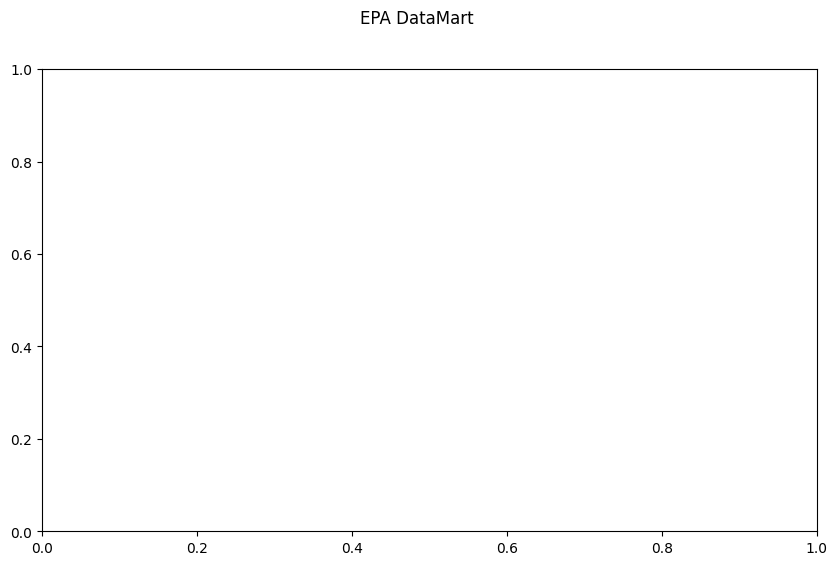

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6),num="Evanston Ozone")
fig.suptitle('EPA DataMart')
ax = fig.add_subplot(1, #nrows
                1, #ncols
                1) # index position
ax.axis([start_dt,end_dt,0,o3_max])
ax.set_title('Hourly Ozone at the Evanston Water Plant')
ax.plot(o3_data['datetime_local'],
        o3_data['sample_measurement'],
        label='EPA: Evanston Ozone (ppm)',
        linestyle='solid',
        linewidth=0.5,
        color='mediumblue',
        alpha=0.5)
ax.plot(o3_data['datetime_local'],
        o3_data['sample_measurement'],
        label='EPA: Evanston Ozone (ppm)',
        linestyle='none',
        linewidth=1,
        marker='o',
        markersize=2,
        mfc='royalblue',
        alpha=0.5)
ax.set_ylabel('Ozone (ppm)')
ax.set_xlabel('Time (local)')
fig.autofmt_xdate()

contrast to daily summary

<h3>Regulatory</h3>

Get codes for local monitoring agencies

In [ ]:
aqs.aqs_mas()    # table of monitoring agencies (MA)


Get code numerical for primary quality assurance organizations


In [ ]:
aqs.aqs_pqaos()  # primary quality assurance organization
